In [6]:
import pandas as pd
import numpy as np
import seaborn as sns

In [9]:
print(pd.__version__)
print(np.__version__)
print(sns.__version__)

2.3.3
2.2.6
0.13.2


In [1]:
! pip install pymongo matplotlib flask

   ---------------------------------------- 0.0/804.8 kB ? eta -:--:--
   ---------------------------------------- 804.8/804.8 kB 33.9 MB/s  0:00:00

   ---------------------------------------- 0/7 [werkzeug]
   ---------------------------------------- 0/7 [werkzeug]
   ---------------------------------------- 0/7 [werkzeug]
   ---------------------------------------- 0/7 [werkzeug]
   ---------------------------------------- 0/7 [werkzeug]
   ----- ---------------------------------- 1/7 [itsdangerous]
   ----------- ---------------------------- 2/7 [dnspython]
   ----------- ---------------------------- 2/7 [dnspython]
   ----------- ---------------------------- 2/7 [dnspython]
   ----------- ---------------------------- 2/7 [dnspython]
   ----------- ---------------------------- 2/7 [dnspython]
   ----------- ---------------------------- 2/7 [dnspython]
   ----------- ---------------------------- 2/7 [dnspython]
   ----------- ---------------------------- 2/7 [dnspython]
   ---------

In [2]:
from pymongo import MongoClient

In [4]:
# MongoDB 로컬 서버 연결
client = MongoClient("mongodb://localhost:27017/")

# MongoDB 데이터베이스 생성
db = client["testDB"]

# 콜렉션 생성 = table
collection = db["students"]

# 데이터 삽입
collection.insert_one({"name": "홍길동", "age":23, "major":"컴퓨터 공학"})





InsertOneResult(ObjectId('69c337f8be821bb4cc7021ce'), acknowledged=True)

In [6]:
# 데이터 조회
for doc in collection.find():
    print(doc)

{'_id': ObjectId('69c337f8be821bb4cc7021ce'), 'name': '홍길동', 'age': 23, 'major': '컴퓨터 공학'}


In [7]:
## 메모리 과부하 생길 수 있으니 DB사용하지 않으면 꼭 close 해주기. 계속사용해야 한다면 열어놓고 있으쇼..
client.close()

## 기본 crud 실습

: CRUD 는 Create, Read, Upadate, Delete

In [8]:
# DB 생성 및 연결 

client = MongoClient("mongodb://localhost:27017/")
db = client["testDB"]
collection = db["students"]

# Create
collection.insert_many(
    [
        {"name":"김현준", "age":27, "major":"컴공"},
        {"name":"장채연", "age":21, "major":"영문학"},
        {"name":"김주희", "age":25, "major":"신학"},
        {"name":"정은영", "age":27, "major":"전자공학"},
        {"name":"노진구", "age":28, "major":"물리학"},
        {"name":"퉁퉁이", "age":31, "major":"국문학"},
        {"name":"임우일", "age":51, "major":"수학"}
    ]
)

InsertManyResult([ObjectId('69c33accbe821bb4cc7021d0'), ObjectId('69c33accbe821bb4cc7021d1'), ObjectId('69c33accbe821bb4cc7021d2'), ObjectId('69c33accbe821bb4cc7021d3'), ObjectId('69c33accbe821bb4cc7021d4'), ObjectId('69c33accbe821bb4cc7021d5'), ObjectId('69c33accbe821bb4cc7021d6')], acknowledged=True)

In [10]:
# 김현준의 나이만 45세로 바꾸기
collection.update_one({"name":"김현준"}, {"$set":{"age":45}})

UpdateResult({'n': 1, 'nModified': 1, 'ok': 1.0, 'updatedExisting': True}, acknowledged=True)

In [12]:
# Delete
collection.delete_one(
    {"name":"퉁퉁이"}
)
collection.delete_one(
    {"name":"노진구"}
)

DeleteResult({'n': 1, 'ok': 1.0}, acknowledged=True)

In [15]:
# Read

for student in collection.find():
    print(student)

client.close()

{'_id': ObjectId('69c337f8be821bb4cc7021ce'), 'name': '홍길동', 'age': 23, 'major': '컴퓨터 공학'}
{'_id': ObjectId('69c33accbe821bb4cc7021d0'), 'name': '김현준', 'age': 45, 'major': '컴공'}
{'_id': ObjectId('69c33accbe821bb4cc7021d1'), 'name': '장채연', 'age': 21, 'major': '영문학'}
{'_id': ObjectId('69c33accbe821bb4cc7021d2'), 'name': '김주희', 'age': 25, 'major': '신학'}
{'_id': ObjectId('69c33accbe821bb4cc7021d3'), 'name': '정은영', 'age': 27, 'major': '전자공학'}
{'_id': ObjectId('69c33accbe821bb4cc7021d6'), 'name': '임우일', 'age': 51, 'major': '수학'}


## Save csv file --> MongoDB

In [16]:
import pandas as pd

# csv 파일 읽기
df = pd.read_csv("./data/Subjects.csv")
df

,class,name,kor,eng,math,science
0,1,aaa,67,87,90,98
1,1,bbb,45,45,56,98
2,1,ccc,95,59,96,88
3,1,ddd,65,94,89,98
4,1,eee,45,65,78,98
5,1,fff,78,76,98,89
6,2,ggg,87,67,65,56
7,2,hhh,89,98,78,78
8,2,iii,100,78,56,65
9,2,jjj,99,89,87,87


In [17]:
# DB 생성 및 연결 
client = MongoClient("mongodb://localhost:27017/")
db = client["testDB"]
collection = db["students_csv"]

# transform df to dictionary
collection.insert_many(
    df.to_dict("records")
) # 데이터프레임을 [{},{},{}, ... ] 형태의 리스트로 변환

print("csv 데이터가 mongodb에 저장되었습니다.")

# read
for students_csv in collection.find():
    print(students_csv)

client.close()

csv 데이터가 mongodb에 저장되었습니다.
{'_id': ObjectId('69c33e07be821bb4cc7021d8'), 'class': 1, 'name': 'aaa', 'kor': 67, 'eng': 87, 'math': 90, 'science': 98}
{'_id': ObjectId('69c33e07be821bb4cc7021d9'), 'class': 1, 'name': 'bbb', 'kor': 45, 'eng': 45, 'math': 56, 'science': 98}
{'_id': ObjectId('69c33e07be821bb4cc7021da'), 'class': 1, 'name': 'ccc', 'kor': 95, 'eng': 59, 'math': 96, 'science': 88}
{'_id': ObjectId('69c33e07be821bb4cc7021db'), 'class': 1, 'name': 'ddd', 'kor': 65, 'eng': 94, 'math': 89, 'science': 98}
{'_id': ObjectId('69c33e07be821bb4cc7021dc'), 'class': 1, 'name': 'eee', 'kor': 45, 'eng': 65, 'math': 78, 'science': 98}
{'_id': ObjectId('69c33e07be821bb4cc7021dd'), 'class': 1, 'name': 'fff', 'kor': 78, 'eng': 76, 'math': 98, 'science': 89}
{'_id': ObjectId('69c33e07be821bb4cc7021de'), 'class': 2, 'name': 'ggg', 'kor': 87, 'eng': 67, 'math': 65, 'science': 56}
{'_id': ObjectId('69c33e07be821bb4cc7021df'), 'class': 2, 'name': 'hhh', 'kor': 89, 'eng': 98, 'math': 78, 'science': 7

## 이미지 --> MongoDB에 저장

In [18]:
import base64
from io import BytesIO

In [20]:
with open("./data/tesla_logo.jpg","rb") as img_file:
    encoded = base64.b64encode(img_file.read()).decode("utf-8")

# DB 생성 및 연결
client = MongoClient("mongodb://localhost:27017/")
db = client["testDB"]
collection = db["images"]

# mongoDB 에 저장
collection.insert_one(
    {"filename":"tesla_logo.jpg","data":encoded}
)

InsertOneResult(ObjectId('69c34476be821bb4cc7021e5'), acknowledged=True)

In [24]:
# 이미지 다시 불러오기
img_data = collection.find_one(
    {"filename":"tesla_logo.jpg"}
)["data"]

# base64 -> 바이너리 변환 -> 이미지 객체로 변환
with open("./data/resotre_tesla_logo.jpg","wb") as out_file:
    out_file.write(base64.b64decode(img_data))

print("이미지를 mongodb에서 불러와 복원했습니다")

이미지를 mongodb에서 불러와 복원했습니다


In [26]:
client.close()

## MongoDB -> 이미지 읽어와 출력

In [27]:
import base64
from io import BytesIO
from PIL import Image
from pymongo import MongoClient
from IPython.display import display

In [30]:
client = MongoClient("mongodb://localhost:27017/")
db = client["testDB"]
collection = db["images"]

MongoDB에서 이미지를 읽어왔습니다.


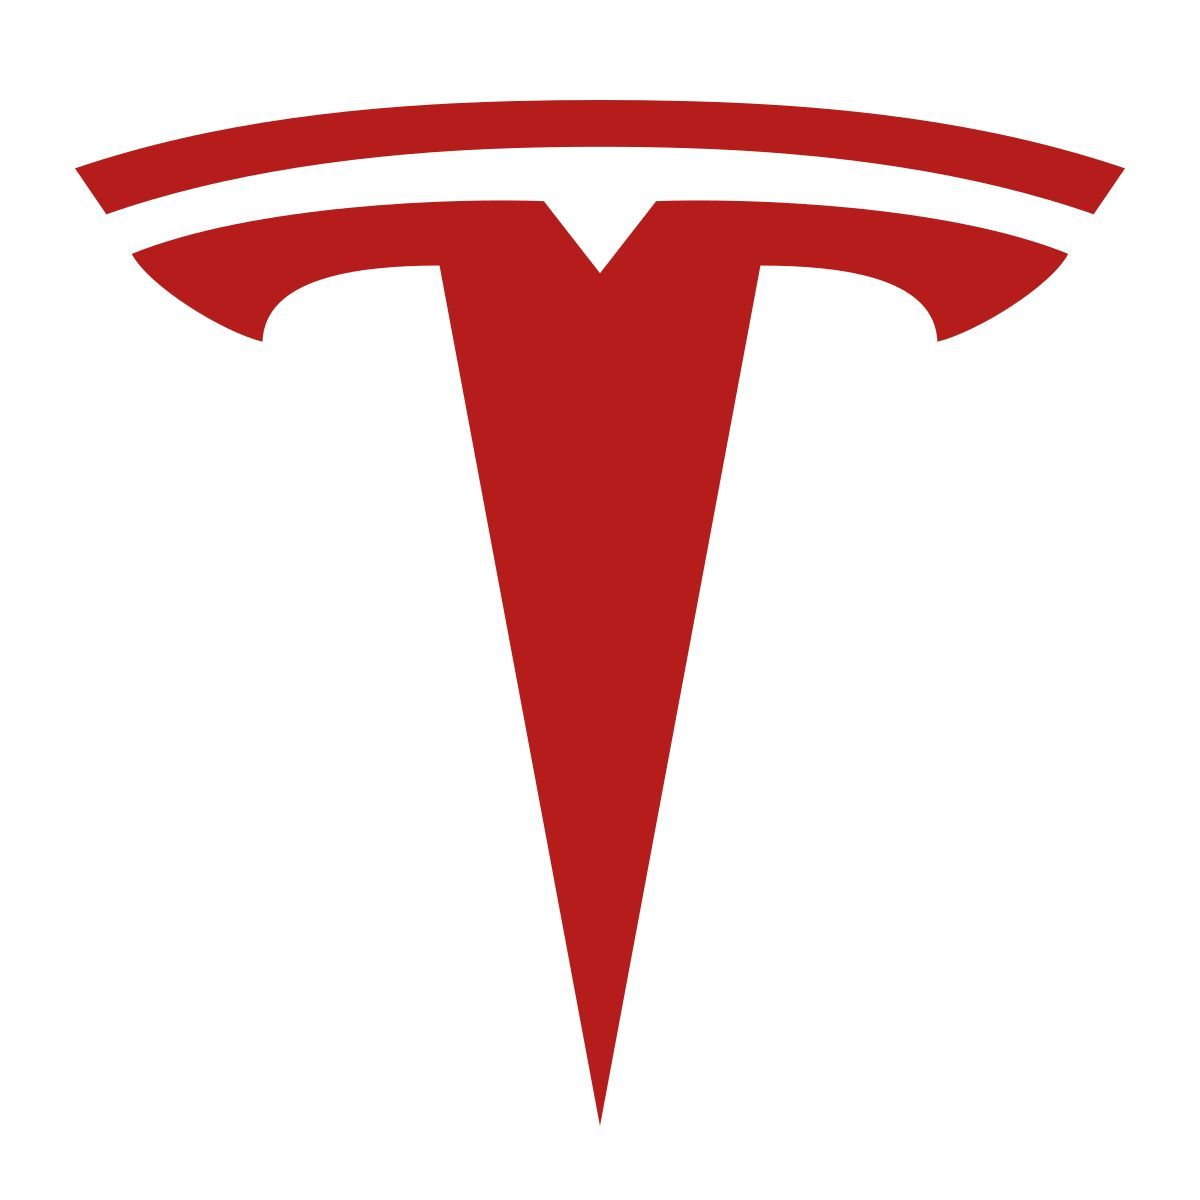

In [34]:
# MongoDB에서 이미지 데이터 가져오기
document = collection.find_one(
    {"filename":"tesla_logo.jpg"}
)

if document:
    img_data = document["data"]
    #base64 -> 바이너리로 변환
    img_binary = base64.b64decode(img_data)
    #메모리에서 바로 이미지 객체 생성
    img = Image.open(BytesIO(img_binary))
    print("MongoDB에서 이미지를 읽어왔습니다.")
    display(img)
else:
    print("tesla_log.jpg 이미지를 찾을 수 없습니다.")

client.close()

## Quiz 1) mongodb에 있는 데이터 읽어와 영어점수 막대 그래프를 출력하기 

In [54]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import font_manager, rc

In [55]:
# 한글 폰트 설정
font_path = "C:/Windows/Fonts/malgun.ttf"
font_name = font_manager.FontProperties(fname=font_path).get_name()
rc('font',family=font_name)

                         _id  class name  kor  eng  math  science
0   69c33e07be821bb4cc7021d8      1  aaa   67   87    90       98
1   69c33e07be821bb4cc7021d9      1  bbb   45   45    56       98
2   69c33e07be821bb4cc7021da      1  ccc   95   59    96       88
3   69c33e07be821bb4cc7021db      1  ddd   65   94    89       98
4   69c33e07be821bb4cc7021dc      1  eee   45   65    78       98
5   69c33e07be821bb4cc7021dd      1  fff   78   76    98       89
6   69c33e07be821bb4cc7021de      2  ggg   87   67    65       56
7   69c33e07be821bb4cc7021df      2  hhh   89   98    78       78
8   69c33e07be821bb4cc7021e0      2  iii  100   78    56       65
9   69c33e07be821bb4cc7021e1      2  jjj   99   89    87       87
10  69c33e07be821bb4cc7021e2      2  kkk   98   45    56       54
11  69c33e07be821bb4cc7021e3      2  lll   65   89    87       78


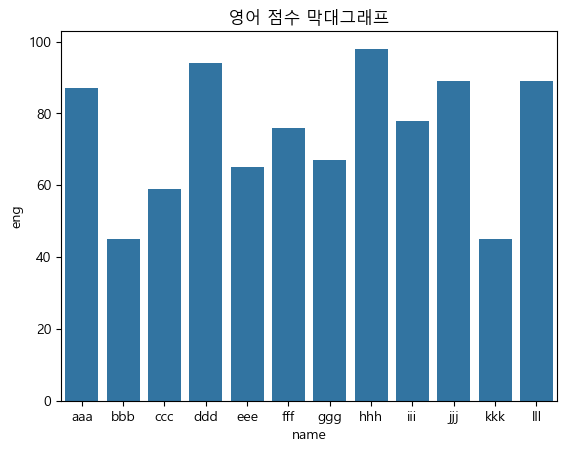

In [56]:
client = MongoClient("mongodb://localhost:27017/")
db = client["testDB"]
collection = db["students_csv"]

students = []

for student in collection.find():
    students.append(student)

df = pd.DataFrame(students)

print(df)

sns.barplot(data = df, x='name', y='eng')
plt.title("영어 점수 막대그래프")
plt.show()

client.close()

## Quiz 2

                        _id name  age   major
0  69c337f8be821bb4cc7021ce  홍길동   23  컴퓨터 공학
1  69c33accbe821bb4cc7021d0  김현준   45      컴공
2  69c33accbe821bb4cc7021d1  장채연   21     영문학
3  69c33accbe821bb4cc7021d2  김주희   25      신학
4  69c33accbe821bb4cc7021d3  정은영   27    전자공학
5  69c33accbe821bb4cc7021d6  임우일   51      수학


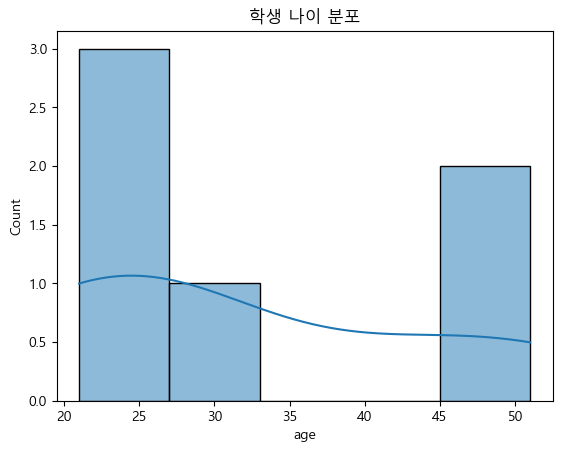

In [68]:
# 음수 값 표시 문제 방지
plt.rcParams['axes.unicode_minus'] = False

client = MongoClient("mongodb://localhost:27017/")
db = client["testDB"]
collection = db["students"]


students = []

for student in collection.find():
    students.append(student)

df = pd.DataFrame(students)
print(df)

sns.histplot(data = df, x='age',bins=5,kde=True)
plt.title("학생 나이 분포")
plt.show()

client.close()

In [69]:
client = MongoClient("mongodb://localhost:27017/")
db = client["testDB"]
collection = db["students"]

cursor = collection.find({})
df = pd.DataFrame(list(cursor))
client.close()

# _id 컬럼 제거
if "_id" in df.columns:
    df = df.drop("_id", axis=1)

print(df)


  name  age   major
0  홍길동   23  컴퓨터 공학
1  김현준   45      컴공
2  장채연   21     영문학
3  김주희   25      신학
4  정은영   27    전자공학
5  임우일   51      수학


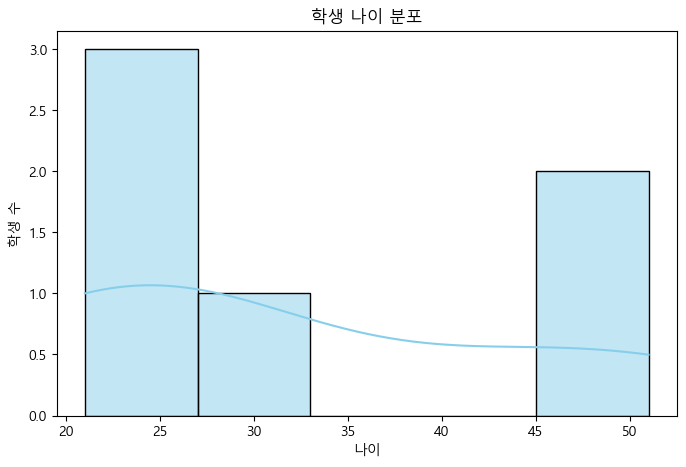

In [70]:
# -----------------------------
#  나이 분포 히스토그램
# -----------------------------
plt.figure(figsize=(8, 5))
sns.histplot(df["age"], bins=5, kde=True, color="skyblue")
plt.title("학생 나이 분포")
plt.xlabel("나이")
plt.ylabel("학생 수")
plt.show()

C:\Users\human\AppData\Local\Temp\ipykernel_8036\3907470155.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="major", data=df, palette="pastel")


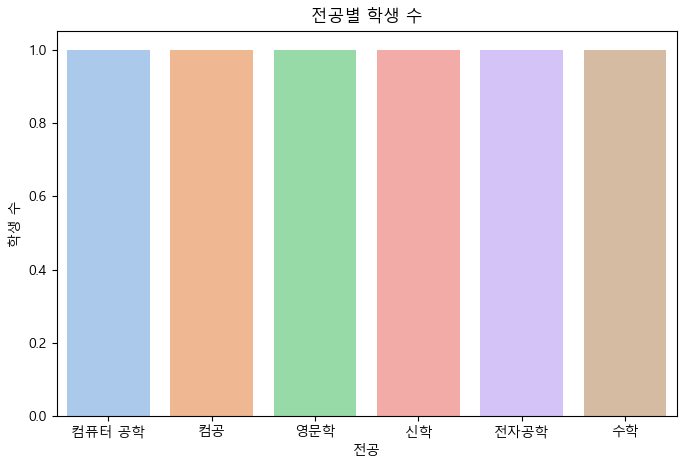

In [71]:
# -----------------------------
#  전공별 학생 수 막대그래프
# -----------------------------
plt.figure(figsize=(8, 5))
sns.countplot(x="major", data=df, palette="pastel")
plt.title("전공별 학생 수")
plt.xlabel("전공")
plt.ylabel("학생 수")
plt.show()

C:\Users\human\AppData\Local\Temp\ipykernel_8036\1748970869.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="major", y="age", data=df, palette="Set2")


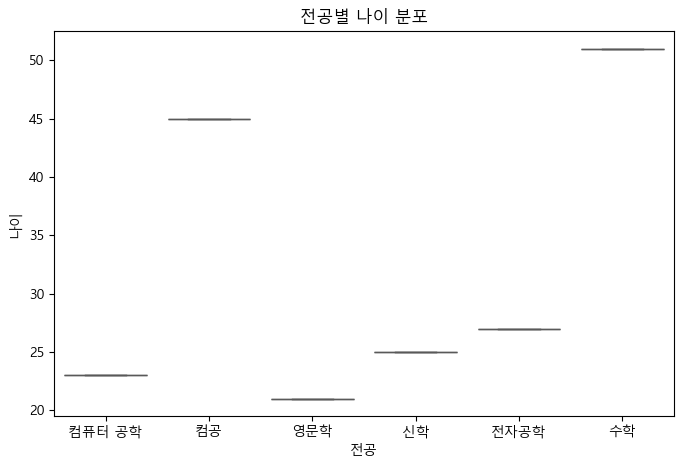

In [72]:
# -----------------------------
#  전공별 나이 분포 박스플롯
# -----------------------------
plt.figure(figsize=(8, 5))
sns.boxplot(x="major", y="age", data=df, palette="Set2")
plt.title("전공별 나이 분포")
plt.xlabel("전공")
plt.ylabel("나이")
plt.show()

In [80]:
import tkinter as tk
from tkinter import ttk
from pymongo import MongoClient
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg
from matplotlib import font_manager, rc

# 한글 폰트 설정 (Windows용)
font_path = "C:/Windows/Fonts/malgun.ttf"
font_name = font_manager.FontProperties(fname=font_path).get_name()
rc('font', family=font_name)

# MongoDB 연결
client = MongoClient("mongodb://localhost:27017/")
db = client["testDB"]
collection = db["students_csv"]

# 데이터 불러오기
data = list(collection.find({}, {"_id": 0}))
df = pd.DataFrame(data)

In [81]:
df

,class,name,kor,eng,math,science
0,1,aaa,67,87,90,98
1,1,bbb,45,45,56,98
2,1,ccc,95,59,96,88
3,1,ddd,65,94,89,98
4,1,eee,45,65,78,98
5,1,fff,78,76,98,89
6,2,ggg,87,67,65,56
7,2,hhh,89,98,78,78
8,2,iii,100,78,56,65
9,2,jjj,99,89,87,87


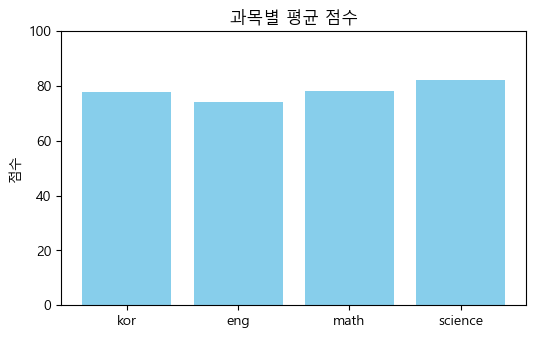

In [82]:
# Tkinter 메인 윈도우
root = tk.Tk()
root.title("학생 점수 대시보드")
root.geometry("900x700")

# === 제목 ===
title_label = tk.Label(root, text="학생 점수 대시보드", font=("Malgun Gothic", 18, "bold"))
title_label.pack(pady=10)

# === Treeview 테이블 ===
frame_table = tk.Frame(root)
frame_table.pack(pady=10)

columns = list(df.columns)
tree = ttk.Treeview(frame_table, columns=columns, show="headings", height=10)

# 컬럼 헤더 설정
for col in columns:
    tree.heading(col, text=col)
    tree.column(col, width=100, anchor="center")

# 데이터 삽입
for _, row in df.iterrows():
    tree.insert("", "end", values=list(row))

tree.pack()

# === Matplotlib 그래프 표시 ===
frame_graph = tk.Frame(root)
frame_graph.pack(pady=20)

# 과목별 평균 계산
mean_scores = df[["kor", "eng", "math", "science"]].mean()

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(mean_scores.index, mean_scores.values, color="skyblue")
ax.set_title("과목별 평균 점수")
ax.set_ylabel("점수")
ax.set_ylim(0, 100)

# Tkinter에 matplotlib 그래프 추가
canvas = FigureCanvasTkAgg(fig, master=frame_graph)
canvas.draw()
canvas.get_tk_widget().pack()

# === 종료 버튼 ===
exit_button = tk.Button(root, text="닫기", command=root.destroy, font=("Malgun Gothic", 12))
exit_button.pack(pady=10)

# Tkinter 실행
root.mainloop()